# Week 3 — Day 2: Linear Regression

## Objective

This notebook develops and evaluates Linear Regression on the scikit-learn Diabetes dataset.

The workflow focuses on:
- fitting and generating predictions,
- interpreting coefficients and the intercept,
- evaluating with MAE, RMSE, and $R^2$,
- comparing against a mean baseline,
- checking whether additional features improve performance,
- and analyzing residuals to assess whether a linear model is appropriate.

A single-feature BMI model is used first for intuition and visualization, then a multiple linear regression model is trained using all available features.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

## 2. Load and Inspect the Dataset

The target is a continuous quantitative measure of diabetes disease progression one year after baseline.

The feature values in this dataset are already transformed/scaled, so coefficient interpretations refer to these transformed feature units rather than original clinical measurement units.

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())

Shape: (442, 11)
Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


## 3. Train/Test Split

A single reproducible 80/20 split is created first.  
Both the BMI-only model and the all-features model will use the same train/test rows so their performance can be compared fairly.

The test set is held out from model fitting.

In [4]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (353, 10)
X_test:  (89, 10)
y_train: (353,)
y_test:  (89,)


# Part A — BMI-Only Linear Regression

Using one feature first makes the prediction equation directly visible:

$\hat{y} = Xw + b$

where \(w\) is the learned coefficient and \(b\) is the intercept.

In [5]:
X_train_bmi = X_train[["bmi"]]
X_test_bmi = X_test[["bmi"]]

bmi_model = LinearRegression()
bmi_model.fit(X_train_bmi, y_train)

bmi_predictions = bmi_model.predict(X_test_bmi)

print(f"Coefficient: {bmi_model.coef_[0]:.4f}")
print(f"Intercept:   {bmi_model.intercept_:.4f}")

Coefficient: 998.5777
Intercept:   152.0034


### Interpreting the BMI Coefficient

The fitted model has the form:

$\hat{y} = w \cdot BMI + b$

A positive BMI coefficient means that, within this one-feature model, higher transformed BMI values are associated with higher predicted target values.

Because the dataset feature is scaled, the coefficient should **not** be interpreted as the effect of a one-unit increase in raw BMI measured in kg/m².

### Manual Prediction Check

To verify that `predict()` is not a black box, one test prediction is recomputed manually using:

$\hat{y} = xw + b$

In [6]:
x = X_test_bmi.iloc[0, 0]

manual_prediction = (
    x * bmi_model.coef_[0]
    + bmi_model.intercept_
)

sklearn_prediction = bmi_model.predict(X_test_bmi.iloc[[0]])[0]

print(f"BMI value:           {x:.6f}")
print(f"Manual prediction:   {manual_prediction:.6f}")
print(f"Sklearn prediction:  {sklearn_prediction:.6f}")

BMI value:           -0.006206
Manual prediction:   145.806227
Sklearn prediction:  145.806227


## 4. Evaluate the BMI-Only Model

- **MAE** measures the average absolute prediction error in target units.
- **RMSE** is also in target units, but penalizes large errors more strongly.
- **$R^2$** measures how much variation is explained relative to a mean-based reference.

A metric should not be judged as “good” or “bad” without context, so a baseline comparison will follow.

In [7]:
bmi_mae = mean_absolute_error(y_test, bmi_predictions)
bmi_rmse = root_mean_squared_error(y_test, bmi_predictions)
bmi_r2 = r2_score(y_test, bmi_predictions)

print(f"MAE:  {bmi_mae:.2f}")
print(f"RMSE: {bmi_rmse:.2f}")
print(f"R²:   {bmi_r2:.3f}")

MAE:  52.26
RMSE: 63.73
R²:   0.233


### Interpretation

With the fixed split used here, the BMI-only model produces approximately:

- MAE ≈ **52.26**
- RMSE ≈ **63.73**
- $R^2$ ≈ **0.233**

The RMSE is noticeably larger than the MAE, indicating that some relatively large prediction errors have a stronger influence on RMSE.

The $R^2$ value indicates that BMI alone explains only part of the variation in the target, so additional features may contain useful predictive information.

## 5. Mean Baseline

The baseline ignores all features and predicts the same value for every test sample: the **mean target value learned from the training set**.

Using the training mean avoids data leakage. The test targets are used only for evaluation.

The question is:

> Does Linear Regression beat a simple strategy that always predicts the training-set mean?

In [8]:
baseline_value = y_train.mean()
baseline_predictions = np.full(len(y_test), baseline_value)

baseline_rmse = root_mean_squared_error(
    y_test,
    baseline_predictions
)

print(f"Training-target mean: {baseline_value:.2f}")
print(f"Baseline RMSE:         {baseline_rmse:.2f}")
print(f"BMI model RMSE:        {bmi_rmse:.2f}")

Training-target mean: 153.74
Baseline RMSE:         73.22
BMI model RMSE:        63.73


### Baseline Interpretation

The baseline RMSE is approximately **73.22**, while the BMI-only model RMSE is approximately **63.73**.

Therefore, the BMI-only Linear Regression model adds predictive value over simply predicting the training-set mean for every test sample.

## 6. Visualizing the BMI Best-Fit Line

### Why this plot?

A scatter plot is appropriate because both BMI and the target are numeric continuous variables.  
With only one feature, the fitted regression relationship can be displayed directly as a line.

- **x-axis:** transformed BMI value
- **y-axis:** target value
- **points:** actual test observations
- **line:** model predictions

This plot is useful for understanding the linear relationship visually; it is not added for decoration.

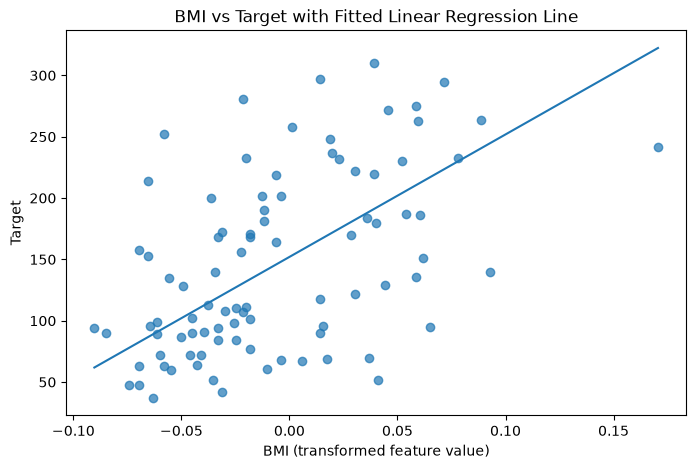

In [9]:
order = np.argsort(X_test_bmi["bmi"].to_numpy())

plt.figure(figsize=(8, 5))
plt.scatter(X_test_bmi["bmi"], y_test, alpha=0.7)
plt.plot(
    X_test_bmi["bmi"].to_numpy()[order],
    bmi_predictions[order]
)

plt.xlabel("BMI (transformed feature value)")
plt.ylabel("Target")
plt.title("BMI vs Target with Fitted Linear Regression Line")
plt.show()

# Part B — Multiple Linear Regression

The full model uses all ten features.

For one observation, prediction can be written as:

$\hat{y} = x \cdot w + b$

For the complete dataset:

$\hat{y} = Xw + b$

So the multiple regression model is a direct application of the dot product and matrix multiplication concepts used in linear algebra.

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Number of coefficients: {len(model.coef_)}")

Intercept: 151.3456
Number of coefficients: 10


## 7. Coefficient Analysis

Each feature receives one coefficient.

A coefficient represents the expected change in the predicted target for a one-unit increase in that transformed feature, **holding the other features constant**.

Because all features are transformed/scaled, comparing coefficient magnitudes is more meaningful here than it would be with completely different raw units. However, coefficient magnitude should still not be treated as causal importance, especially when predictors are correlated.

In [11]:
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_,
    "abs_coefficient": np.abs(model.coef_)
})

coefficients = coefficients.sort_values(
    "abs_coefficient",
    ascending=False
)

coefficients

,feature,coefficient,abs_coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


### Coefficient Interpretation

For this fitted model, the largest absolute coefficients are approximately:

- **s1:** -931.49
- **s5:** +736.20
- **bmi:** +542.43
- **s2:** +518.06

The negative sign for `s1` indicates an inverse linear association with the predicted target after controlling for the other predictors, while positive coefficients indicate positive associations.

The largest absolute coefficient is **not** automatically the “most important cause.” Coefficients describe this fitted linear model, not causation.

## 8. Evaluate the All-Features Model

In [12]:
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

MAE:  42.79
RMSE: 53.85
R²:   0.453


### Evaluation Interpretation

The all-features model produces approximately:

- MAE ≈ **42.79**
- RMSE ≈ **53.85**
- $R^2$ ≈ **0.453**

Compared with the BMI-only model, both MAE and RMSE decrease, while $R^2$ increases substantially.

This means the additional predictors contribute useful information beyond BMI alone.

## 9. Model Comparison

The RMSE comparison provides a direct performance ladder:

**Mean baseline → BMI-only model → all-features model**

Lower RMSE is better.

In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "BMI-only Linear Regression",
        "All-features Linear Regression"
    ],
    "RMSE": [
        baseline_rmse,
        bmi_rmse,
        rmse
    ]
})

comparison

,Model,RMSE
0,Mean Baseline,73.222493
1,BMI-only Linear Regression,63.732456
2,All-features Linear Regression,53.853446


### Comparison Insight

Approximate RMSE values:

- Mean baseline: **73.22**
- BMI-only Linear Regression: **63.73**
- All-features Linear Regression: **53.85**

The all-features model clearly outperforms both simpler references on the same held-out test set.

This is a stronger conclusion than saying “RMSE = 53.85 is good,” because the number is interpreted relative to meaningful alternatives.

## 10. Residual Analysis

Residuals are defined as:

$Residual = Actual - Predicted$

- Positive residual → the model underpredicted.
- Negative residual → the model overpredicted.

A residual plot is useful because Linear Regression should ideally leave errors that are scattered around zero without a strong systematic pattern.

In [14]:
residuals = y_test - predictions

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
    "Residual": residuals
})

results.head(10)

,Actual,Predicted,Residual
287,219.0,139.547558,79.452442
211,70.0,179.517208,-109.517208
72,202.0,134.038756,67.961244
321,230.0,291.417029,-61.417029
73,111.0,123.789659,-12.789659
418,84.0,92.172347,-8.172347
367,242.0,258.232389,-16.232389
354,272.0,181.337321,90.662679
281,94.0,90.224113,3.775887
148,96.0,108.633759,-12.633759


### Why Residuals vs Predicted Values?

This plot checks whether prediction errors appear approximately random across the prediction range.

- **x-axis:** predicted target values
- **y-axis:** residuals
- **horizontal zero line:** perfect prediction

A strong curve, funnel shape, or other structured pattern would suggest that the linear model is missing systematic structure in the data.

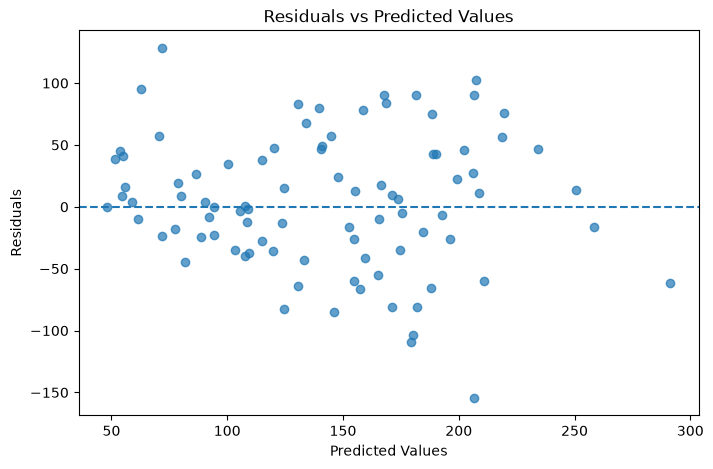

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(predictions, residuals, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

### Residual Insight

The residuals appear on both sides of zero, but the spread is not perfectly random and several relatively large residuals remain.

This suggests that the linear model captures a meaningful part of the relationship, but does not explain all structure in the data.

That conclusion is consistent with $R^2 \approx 0.45$: the model improves substantially over the baseline, while a considerable amount of target variation remains unexplained.

# Conclusion

The main findings are:

1. Linear Regression predictions follow the linear algebra form $\hat{y} = Xw + b$.
2. A BMI-only model beats the mean baseline, showing that BMI contains useful predictive signal.
3. Using all ten features improves MAE, RMSE, and $R^2$ substantially.
4. The all-features model achieves an RMSE of about **53.85**, compared with about **73.22** for the mean baseline.
5. Coefficients provide interpretable linear associations, but should not be treated as causal effects.
6. Residual analysis shows that Linear Regression captures useful structure but is not a perfect description of the dataset.

Overall, Linear Regression provides a useful, interpretable baseline model for this regression task, while the remaining residual structure indicates room for models that can represent more complex relationships.